In [ ]:
!nvidia-smi

Sat May  9 06:29:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 1 . Cupy

In [ ]:
import numpy as np
import cupy as cp

In [ ]:
array_cpu = np.ones((5,5))
print(array_cpu)
print(type(array_cpu))

[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]
<class 'numpy.ndarray'>


In [ ]:
array_gpu = cp.ones((5,5))
print(array_gpu)
print(type(array_gpu))

[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]
<class 'cupy.ndarray'>


In [ ]:
array_cpu = np.array([1,2,3,4,5])
array_move_gpu = cp.asarray(array_cpu)

array_regreso_cpu = cp.asnumpy(array_move_gpu)
type(array_cpu), type(array_move_gpu), type(array_regreso_cpu)

(numpy.ndarray, cupy.ndarray, numpy.ndarray)

In [ ]:
size = 10000
A_cpu = np.random.rand(size,size)
B_cpu = np.random.rand(size,size)

A_gpu = cp.random.rand(size,size)
B_gpu = cp.random.rand(size,size)

In [ ]:
%%timeit -n 3
mult_A_B_cpu = np.dot(A_cpu, B_cpu)

35.2 s ± 402 ms per loop (mean ± std. dev. of 7 runs, 3 loops each)


In [ ]:
%%timeit -n 3
mult_A_B_gpu = cp.dot(A_gpu, B_gpu)
cp.cuda.Stream.null.synchronize() # Las operaciones en GPU son asíncronas

8.1 s ± 45.6 ms per loop (mean ± std. dev. of 7 runs, 3 loops each)


In [ ]:
A_cpu.nbytes / 1024 / 1024

762.939453125

In [ ]:
from scipy.fft import fftn

In [ ]:
%%timeit
fftn(A_cpu)

2.54 s ± 337 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
from cupyx.scipy.fft import fftn as fftn_gpu

In [ ]:
%%timeit -n 1
fftn_gpu(A_gpu)

The slowest run took 37.53 times longer than the fastest. This could mean that an intermediate result is being cached.
562 µs ± 1.11 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# 2. Nuba

In [ ]:
from numba import cuda

In [ ]:
cuda.get_current_device().name

'Tesla T4'

In [ ]:
def suma_vectores(a,b,c):
  for i in range(a.size):
    c[i] = a[i] + b[i]

In [ ]:
size = 10000000
A = np.ones(size)
B = np.ones(size)
C_cpu = np.zeros(size)

In [ ]:
%%timeit
suma_vectores(A,B,C_cpu)

3.44 s ± 495 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
# Compilar esta funcion en GPU
@cuda.jit
def suma_vectores_gpu(a,b,c):
  # Nos da el identificador del hilo actual
  i = cuda.grid(1)

  # verificar que no se acceda a un indice fuera del arreglo
  if i < a.size:
    c[i] = a[i] + b[i]

In [ ]:
hilos_por_bloque = 256
bloques_por_grid = (size + hilos_por_bloque - 1) // hilos_por_bloque

In [ ]:
C_gpu = np.zeros(size)

In [ ]:
%%timeit
suma_vectores_gpu[bloques_por_grid, hilos_por_bloque](A, B, C_gpu)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:934: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


168 ms ± 69.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
hilos_por_bloque = 512
bloques_por_grid = (size + hilos_por_bloque - 1) // hilos_por_bloque
suma_vectores_gpu[bloques_por_grid, hilos_por_bloque](A, B, C_gpu)

In [ ]:
C_gpu

array([2., 2., 2., ..., 2., 2., 2.])

# 3. Kernel personalizado (Convoluciones)

Librerías importadas.
Imagen cargada. Resolución: 719x761 píxeles.


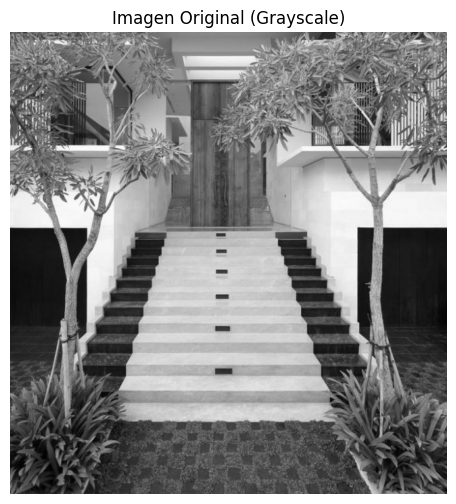

In [ ]:
import numpy as np
from numba import cuda, float32
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

url_imagen = "http://verfachadasdecasas.com/wp-content/uploads/2017/11/modelos-de-escaleras-para-entrada-de-casa.jpg"
response = requests.get(url_imagen)
img_pil = Image.open(BytesIO(response.content))

# --- Convertir a Escala de Grises ---
# Sobel funciona mejor sobre la intensidad de brillo, no sobre colores RGB.
img_gray = img_pil.convert('L')

# --- Convertir a Arreglo de Numpy ---
imagen_cpu = np.array(img_gray).astype(np.float32)
alto, ancho = imagen_cpu.shape

print(f"Imagen cargada. Resolución: {ancho}x{alto} píxeles.")

# Mostrar imagen original
plt.figure(figsize=(6,6))
plt.imshow(imagen_cpu, cmap='gray')
plt.title("Imagen Original (Grayscale)")
plt.axis('off')
plt.show()

In [ ]:
import math

@cuda.jit
def kernel_sobel(imagen_entrada, imagen_x, imagen_y, imagen_salida):
    # Obtener la posición 2D del hilo
    x, y = cuda.grid(2)

    alto, ancho = imagen_entrada.shape

    # Solo procesamos si el filtro 3x3 "cabe" centrado en este píxel.
    # Evitamos x=0, x=ancho-1, y=0, y=alto-1.
    if x > 0 and x < (ancho - 1) and y > 0 and y < (alto - 1):

        # --- Aplicar Núcleo Gx (Bordes Verticales) ---
        # Gx = [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]
        # Leemos los 9 píxeles (el centro y los 8 vecinos) y multiplicamos
        val_gx = (
            -1.0 * imagen_entrada[y-1, x-1] +  1.0 * imagen_entrada[y-1, x+1] +
            -2.0 * imagen_entrada[y,   x-1] +  2.0 * imagen_entrada[y,   x+1] +
            -1.0 * imagen_entrada[y+1, x-1] +  1.0 * imagen_entrada[y+1, x+1]
        )

        # --- Aplicar Núcleo Gy (Bordes Horizontales) ---
        # Gy = [[-1, -2, -1], [0, 0, 0], [1, 2, 1]]
        val_gy = (
            -1.0 * imagen_entrada[y-1, x-1] + -2.0 * imagen_entrada[y-1, x] + -1.0 * imagen_entrada[y-1, x+1] +
             1.0 * imagen_entrada[y+1, x-1] +  2.0 * imagen_entrada[y+1, x] +  1.0 * imagen_entrada[y+1, x+1]
        )

        # --- Calcular Magnitud del Gradiente ---
        # La fuerza del borde es sqrt(Gx^2 + Gy^2)
        magnitud = math.sqrt(val_gx**2 + val_gy**2)

        # Guardar resultados
        imagen_salida[y, x] = magnitud
        imagen_x[y, x] = val_gx
        imagen_y[y, x] = val_gy

In [ ]:
# --- 1. Preparar memoria en la GPU ---
print("Copiando imagen a la GPU...")
imagen_gpu = cuda.to_device(imagen_cpu)

# Creamos un arreglo vacío en la GPU para el resultado
resultado_gpu_x = cuda.device_array((alto, ancho), dtype=np.uint8)
resultado_gpu_y = cuda.device_array((alto, ancho), dtype=np.uint8)
resultado_gpu = cuda.device_array((alto, ancho), dtype=np.uint8)


# --- Configurar la Grilla 2D (Hilos y Bloques) ---
# Usamos bloques de 16x16 = 256 hilos (cumple la regla del Warp de 32)
hilos_por_bloque = (16, 16)

# Calculamos bloques necesarios (ceil)
bloques_x = math.ceil(ancho / hilos_por_bloque[0])
bloques_y = math.ceil(alto / hilos_por_bloque[1])
bloques_por_grid = (bloques_x, bloques_y)

print(f"Lanzando kernel Sobel ({bloques_por_grid} bloques)...")

# --- Ejecutar ---
kernel_sobel[bloques_por_grid, hilos_por_bloque](imagen_gpu, resultado_gpu_x, resultado_gpu_y, resultado_gpu)

# Forzar sincronización
cuda.synchronize()

print("Copiando resultado de vuelta a CPU...")
imagen_final_cpu_x = resultado_gpu_x.copy_to_host()
imagen_final_cpu_y = resultado_gpu_y.copy_to_host()
imagen_final_cpu = resultado_gpu.copy_to_host()

Copiando imagen a la GPU...
Lanzando kernel Sobel ((45, 48) bloques)...
Copiando resultado de vuelta a CPU...


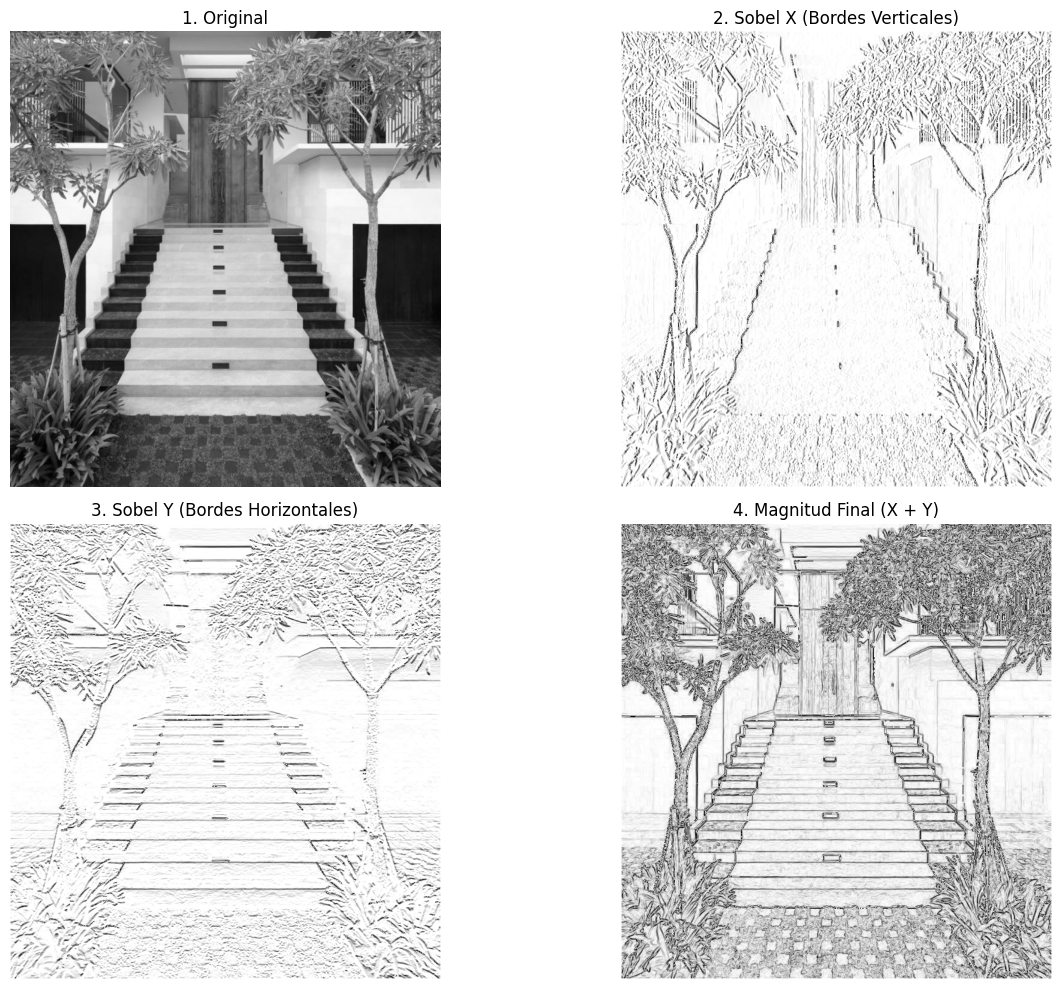

In [ ]:
# --- Mostrar Resultados ---
# Creamos una figura con tamaño suficiente para 4 imágenes
plt.figure(figsize=(14, 10))

# 1. Imagen Original
plt.subplot(2, 2, 1)
plt.imshow(imagen_cpu, cmap='gray')
plt.title("1. Original")
plt.axis('off')

# 2. Gradiente Horizontal (Eje X)
plt.subplot(2, 2, 2)
plt.imshow(imagen_final_cpu_x, cmap='gray_r')
plt.title("2. Sobel X (Bordes Verticales)")
plt.axis('off')

# 3. Gradiente Vertical (Eje Y)
plt.subplot(2, 2, 3)
plt.imshow(imagen_final_cpu_y, cmap='gray_r')
plt.title("3. Sobel Y (Bordes Horizontales)")
plt.axis('off')

# 4. Magnitud del Gradiente (Resultado Final)
plt.subplot(2, 2, 4)
plt.imshow(imagen_final_cpu, cmap='gray_r')
plt.title("4. Magnitud Final (X + Y)")
plt.axis('off')

# Ajusta automáticamente el espacio entre subplots para que no se encimen los títulos
plt.tight_layout()
plt.show()